In [2]:
%pip install -U langchain langchain-openai langchain-community langchain-chroma langgraph
%pip install pypdf -q

  Using cached langchain-1.3.11-py3-none-any.whl.metadata (6.0 kB)
  Using cached langchain_openai-1.3.3-py3-none-any.whl.metadata (3.4 kB)
  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached langchain_chroma-1.1.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached langgraph-1.2.7-py3-none-any.whl.metadata (4.9 kB)
  Using cached langchain_core-1.4.8-py3-none-any.whl.metadata (4.7 kB)
  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached tiktoken-0.13.0-cp311-cp311-win_amd64.whl.metadata (6.8 kB)
  Using cached aiohttp-3.14.1-cp311-cp311-win_amd64.whl.metadata (8.5 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pydantic_settings-2.14.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import os
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Sequence
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, ToolMessage
from operator import add as add_messages
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.tools import tool

In [5]:
#use openAI API key to use the LLM 
#call the API key as an environment variable
#to manage API key as a local enviornment variable we need OS library, and to load the env variables from .env file we need to install python-dotenv package
%pip install python-dotenv

import os

#load openai key from .env file, first import the library to load env variables
from dotenv import load_dotenv
from pathlib import Path

env_path=Path.cwd() /'.env'#give the .env file path
print("Path to .env file:", env_path)
print("File exists:", env_path.exists())
# Load environment variables from .env file
load_dotenv(env_path,override=True)


#OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
api_key = os.getenv("OPENAI_API_KEY")
print("Loaded:", api_key is not None)

Note: you may need to restart the kernel to use updated packages.
Path to .env file: c:\Users\shara\OneDrive\Documents\Coding Stuff\Generative AI\LangChain\LangGraph\.env
File exists: True
Loaded: True



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
llm = ChatOpenAI(model="gpt-4o", temperature = 0)

In [8]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small",)

In [12]:
pdf_loader = PyPDFLoader("/Users/shara/OneDrive/Documents/Coding Stuff/Generative AI/LangChain/Documents/global_warming.pdf")

In [13]:
pages = pdf_loader.load()

incorrect startxref pointer(1)
parsing for Object Streams


In [17]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)

In [15]:
pages_split = text_splitter.split_documents(pages)

In [16]:
len(pages_split)

9

In [18]:
vectorstore = Chroma.from_documents(documents=pages_split,embedding=embeddings,persist_directory="./vectorstore",collection_name="data")

In [19]:
retriever = vectorstore.as_retriever(search_type="similarity",search_kwargs={"k": 3})

In [23]:
@tool
def retriever_tool(query: str) -> str:
    """
    This tool searches and returns the information about globl warming.
    """
    docs = retriever.invoke(query)
    if not docs:
        return "I found no relevant information"
    results = []
    for i, doc in enumerate(docs):
        results.append(f"Document {i+1}:\n{doc.page_content}")

    return "\n\n".join(results)

In [24]:
tools = [retriever_tool]

llm_with_tools = llm.bind_tools(tools)

In [22]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [25]:
def should_continue(state: AgentState):
    """Check if the last message contains a tool call."""
    result = state['messages'][-1]
    return hasattr(result, 'tool_calls') and len(result.tool_calls) > 0

In [36]:
system_prompt = """
You are an intelligent AI assistant who answers questions about global warming based on the PDF document loaded into your knowledge base.
Use the retriever tool available to answer questions about the given data. You can make multiple calls if needed.
If you need to look up some information before asking a follow up question, you are allowed to do that!
Please always cite the specific parts of the documents you use in your answers. Use the tools only when they are required.Else answer bsed on your knowledge
"""

In [37]:
tools_dict = {our_tool.name: our_tool for our_tool in tools}

In [38]:
# LLM Agent
def call_llm(state: AgentState) -> AgentState:
    """Function to call the LLM with the current state."""
    messages = list(state['messages'])
    messages = [SystemMessage(content=system_prompt)] + messages
    message = llm_with_tools.invoke(messages)
    print(message)
    return {'messages': [message]}

In [40]:
# Retriever Agent
def take_action(state: AgentState) -> AgentState:
    """Execute tool calls from the LLM's response."""

    tool_calls = state['messages'][-1].tool_calls
    results = []
    for t in tool_calls:
        print(f"Calling Tool: {t['name']} with query: {t['args'].get('query', 'No query provided')}")

        if not t['name'] in tools_dict: # Checks if a valid tool is present
            print(f"\nTool: {t['name']} does not exist.")
            result = "Incorrect Tool Name, Please Retry and Select tool from List of Available tools."

        else:
            result = tools_dict[t['name']].invoke(t['args'].get('query', ''))
            print(f"Result length: {len(str(result))}")


        # Appends the Tool Message
        results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))

    print("Tools Execution Complete. Back to the model!")
    return {'messages': results}

In [41]:
workflow = StateGraph(AgentState)

workflow.add_node("llm", call_llm)
workflow.add_node("retriever_agent", take_action)

workflow.add_edge(START, "llm")
workflow.add_conditional_edges(
    "llm",
    should_continue,
    {True: "retriever_agent", False: END}
)
workflow.add_edge("retriever_agent", "llm")

app = workflow.compile()

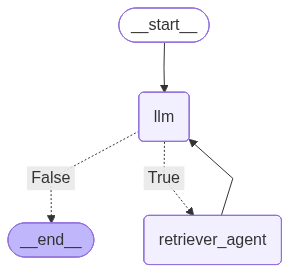

In [42]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
result = app.invoke({"messages": [HumanMessage(content="what is global warming")]})

content='Global warming refers to the long-term increase in Earth\'s average surface temperature due to human activities, primarily the emission of greenhouse gases such as carbon dioxide (CO2), methane (CH4), and nitrous oxide (N2O). These gases trap heat in the atmosphere, leading to a "greenhouse effect," which results in the warming of the planet. This phenomenon is a significant aspect of climate change and has various environmental impacts, including rising sea levels, changing weather patterns, and increased frequency of extreme weather events.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 104, 'prompt_tokens': 154, 'total_tokens': 258, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_35ed4b

In [44]:
result['messages'][-1].content

'Global warming refers to the long-term increase in Earth\'s average surface temperature due to human activities, primarily the emission of greenhouse gases such as carbon dioxide (CO2), methane (CH4), and nitrous oxide (N2O). These gases trap heat in the atmosphere, leading to a "greenhouse effect," which results in the warming of the planet. This phenomenon is a significant aspect of climate change and has various environmental impacts, including rising sea levels, changing weather patterns, and increased frequency of extreme weather events.'

In [45]:
result = app.invoke({"messages": [HumanMessage(content="what is blockchain")]})

content='Blockchain is a distributed ledger technology that allows data to be stored across a network of computers in a way that ensures security, transparency, and immutability. Each block in a blockchain contains a list of transactions, and once a block is added to the chain, it cannot be altered without changing all subsequent blocks, which requires consensus from the network. This makes blockchain highly secure against tampering and fraud.\n\nKey features of blockchain include:\n\n1. **Decentralization**: Unlike traditional databases that are controlled by a central authority, a blockchain is maintained by a network of nodes, each of which has a copy of the entire blockchain.\n\n2. **Transparency**: All transactions on a blockchain are visible to all participants, which enhances trust and accountability.\n\n3. **Immutability**: Once data is recorded on a blockchain, it is extremely difficult to change, providing a permanent and tamper-proof record.\n\n4. **Consensus Mechanisms**: B